# Random Forest - Nataly

We implemented and analyzed a Random Forest classifier to predict whether a mushroom is edible or poisonous using the UCI Mushroom Dataset. Unlike a single decision tree, a random forest combines predictions from many trees with randomized features and samples, which typically leads to better generalization and reduced overfitting.

# 1. Load the Processed Dataset 

In [1]:
# Load the Processed Dataset
import pandas as pd

df = pd.read_csv("../Sources/data/processed_mushrooms.csv")

df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,1,5,2,4,1,6,1,0,1,4,...,2,2,7,7,2,1,4,2,3,5
1,0,5,2,9,1,0,1,0,0,4,...,2,2,7,7,2,1,4,3,2,1
2,0,0,2,8,1,3,1,0,0,5,...,2,2,7,7,2,1,4,3,2,3
3,1,5,3,8,1,6,1,0,1,5,...,2,2,7,7,2,1,4,2,3,5
4,0,5,2,3,0,5,1,1,0,4,...,2,2,7,7,2,1,0,3,0,1


# 2. Separate Features and Target

In [2]:
# Separate Features and Target
X = df.drop("class", axis=1)
y = df["class"]

# 3. Train/Test Split (80/20)


In [3]:
# Train/Test Split (80/20)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 4. Train Random Forest Classifier with default parameters (100 trees)


In [4]:
# Train Random Forest Classifier with default parameters (100 trees)
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [5]:
# Make Predictions
y_pred = rf.predict(X_test)

# 5. Evaluate Performance

In [6]:
# Evaluate Performance using Accuracy, Precision, Recall, and F-1 Score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("RANDOM FOREST RESULTS (100 trees)")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F-1 Score:", f1_score(y_test, y_pred))

RANDOM FOREST RESULTS (100 trees)
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F-1 Score: 1.0


The Random Forest classifier with 100 trees demonstrates strong performance on the mushroom classification task. The high accuracy, precision, recall, and F-1 score indicate that the ensemble method successfully combines information from multiple decision trees to accurately distinguish between edible and poisonous mushrooms.

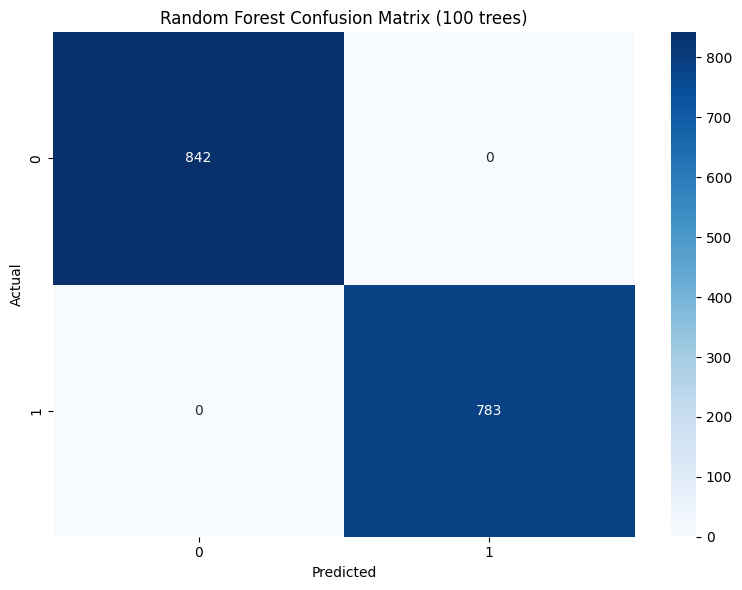

In [7]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=True)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix (100 trees)")
plt.tight_layout()
plt.show()

# 7. Determine Feature Importance

In [8]:
# Feature Importance from Random Forest
feature_importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("Top 10 Important Features:")
print(feature_importance.head(10))

Top 10 Important Features:
odor                        0.205451
gill-color                  0.128818
gill-size                   0.117642
spore-print-color           0.091491
ring-type                   0.069849
bruises                     0.051699
population                  0.051216
stalk-root                  0.043897
stalk-surface-above-ring    0.039528
gill-spacing                0.035800
dtype: float64


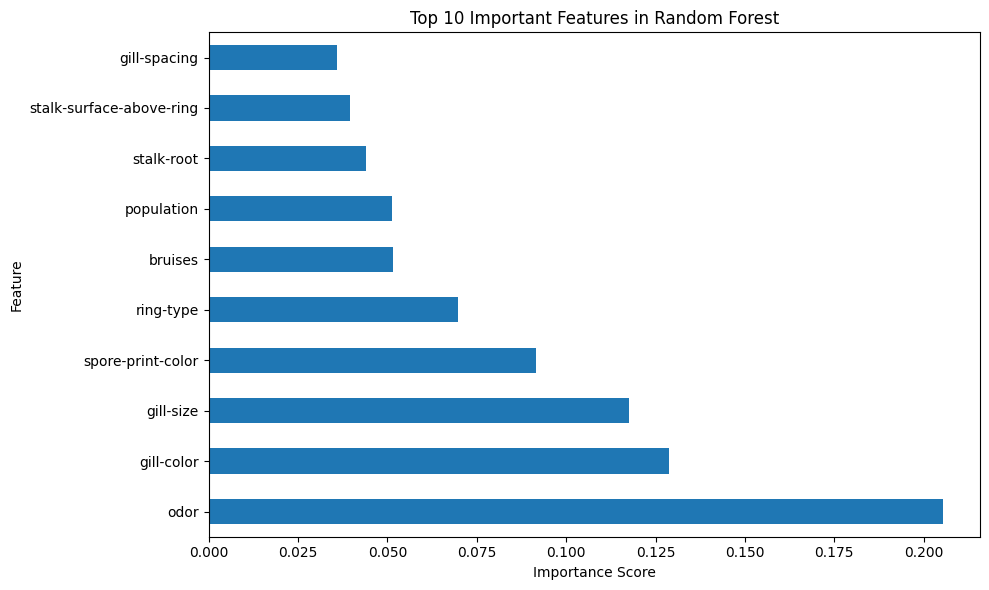

In [9]:
# Plot Feature Importance
plt.figure(figsize=(10, 6))
feature_importance.head(10).plot(kind="barh")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Top 10 Important Features in Random Forest")
plt.tight_layout()
plt.show()

The feature importance scores reveal which characteristics of mushrooms are most predictive for classification. Features with higher importance scores are used more frequently and earlier in the decision trees throughout the forest. This visualization shows the top 10 features that contribute most to the model's predictions across all trees in the ensemble.

# 8. Comparing Training and Testing Accuracy

In [10]:
# Train/Test Accuracy Comparison
train_acc = rf.score(X_train, y_train)
test_acc = rf.score(X_test, y_test)

print("Training Accuracy:", train_acc)
print("Test Accuracy:", test_acc)
print("Difference:", train_acc - test_acc)

Training Accuracy: 1.0
Test Accuracy: 1.0
Difference: 0.0


# 9. Comparing Different Numbers of Trees

In [11]:
# Analyze how different numbers of trees affect model performance
n_trees_list = [10, 25, 50, 100, 150, 200]
train_accuracies = []
test_accuracies = []

for n_trees in n_trees_list:
    rf_temp = RandomForestClassifier(
        n_estimators=n_trees,
        random_state=42,
        n_jobs=-1
    )
    rf_temp.fit(X_train, y_train)
    train_accuracies.append(rf_temp.score(X_train, y_train))
    test_accuracies.append(rf_temp.score(X_test, y_test))

results_df = pd.DataFrame({
    'n_estimators': n_trees_list,
    'train_accuracy': train_accuracies,
    'test_accuracy': test_accuracies
})

print(results_df)

   n_estimators  train_accuracy  test_accuracy
0            10             1.0            1.0
1            25             1.0            1.0
2            50             1.0            1.0
3           100             1.0            1.0
4           150             1.0            1.0
5           200             1.0            1.0


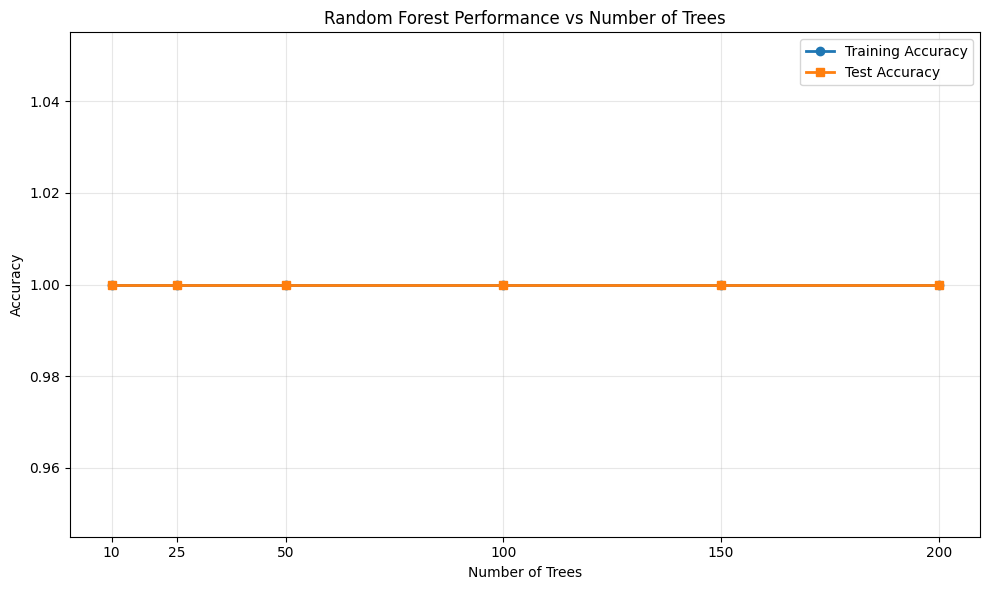

In [12]:
# Plot Training vs Test Accuracy across different numbers of trees
plt.figure(figsize=(10, 6))
plt.plot(n_trees_list, train_accuracies, marker='o', label='Training Accuracy', linewidth=2)
plt.plot(n_trees_list, test_accuracies, marker='s', label='Test Accuracy', linewidth=2)
plt.xlabel('Number of Trees')
plt.ylabel('Accuracy')
plt.title('Random Forest Performance vs Number of Trees')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(n_trees_list)
plt.tight_layout()
plt.show()